In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, accuracy_score, classification_report)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19, InceptionV3
from tensorflow.keras.optimizers import Adam
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Dataset paths
TRAIN_DIR = "/content/drive/MyDrive/Colab Notebooks/Colab Notebooks/Jute_Pest_Dataset_Split/train"
VALID_DIR = "/content/drive/MyDrive/Colab Notebooks/Colab Notebooks/Jute_Pest_Dataset_Split/val"
TEST_DIR = "/content/drive/MyDrive/Colab Notebooks/Colab Notebooks/Jute_Pest_Dataset_Split/test"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.001


In [5]:
# Data generators with augmentation (following the research paper)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")
print(f"Class indices: {train_generator.class_indices}")


Found 5005 images belonging to 17 classes.
Found 1073 images belonging to 17 classes.
Found 1102 images belonging to 17 classes.
Number of classes: 17
Class indices: {'Beet Armyworm': 0, 'Black Hairy': 1, 'Cutworm': 2, 'Field Cricket': 3, 'Jute Aphid': 4, 'Jute Hairy': 5, 'Jute Red Mite': 6, 'Jute Semilooper': 7, 'Jute Stem Girdler': 8, 'Jute Stem Weevil': 9, 'Leaf Beetle': 10, 'Mealybug': 11, 'Pod Borer': 12, 'Scopula Emissaria': 13, 'Termite': 14, 'Termite odontotermes (Rambur)': 15, 'Yellow Mite': 16}


In [6]:
def build_pretrained_model(base_model, num_classes, model_name):
    """
    Build fine-tuned pre-trained model following the research paper
    - Replace classification layer with global average pooling
    - Add dropout layer (30%)
    - Add dense layer with softmax
    """
    # Freeze base model layers
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Load pre-trained models
print("\n" + "="*70)
print("Loading Pre-trained Models...")
print("="*70)

# VGG19 Model
vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
vgg19_model = build_pretrained_model(vgg19_base, num_classes, 'VGG19')

# InceptionV3 Model
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
inception_model = build_pretrained_model(inception_base, num_classes, 'InceptionV3')


Loading Pre-trained Models...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [7]:
optimizer = Adam(learning_rate=LEARNING_RATE)
loss_fn = keras.losses.CategoricalCrossentropy()

# VGG19
vgg19_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# InceptionV3
inception_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

print("\n" + "="*70)
print("Model Summaries")
print("="*70)
print("\nVGG19:")
vgg19_model.summary()
print("\n\nInceptionV3:")
inception_model.summary()


Model Summaries

VGG19:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 17)             │         8,721 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033,105 (76.42 MB)

 Trainable params: 8,721 (34.07 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │        34,833 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,837,617 (83.30 MB)

 Trainable params: 34,833 (136.07 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [8]:
import os

print("\n" + "="*70)
print("Setting up Callbacks...")
print("="*70)

# Google Drive paths for Colab
checkpoint_dir = '/content/drive/MyDrive/Colab Notebooks/checkpoints'

# Create directory for checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"✓ Checkpoint directory ready: {checkpoint_dir}")

# Callbacks for VGG19
vgg19_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

vgg19_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    mode='max',
    min_lr=1e-7,
    verbose=1
)

vgg19_checkpoint = keras.callbacks.ModelCheckpoint(
    os.path.join(checkpoint_dir, 'vgg19_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

vgg19_callbacks = [vgg19_early_stopping, vgg19_reduce_lr, vgg19_checkpoint]

# Callbacks for InceptionV3
inception_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

inception_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    mode='max',
    min_lr=1e-7,
    verbose=1
)

inception_checkpoint = keras.callbacks.ModelCheckpoint(
    os.path.join(checkpoint_dir, 'inception_v3_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

inception_callbacks = [inception_early_stopping, inception_reduce_lr, inception_checkpoint]

print("✓ Callbacks configured successfully")


Setting up Callbacks...
✓ Checkpoint directory ready: /content/drive/MyDrive/Colab Notebooks/checkpoints
✓ Callbacks configured successfully


In [9]:
print("\n" + "="*70)
print("Training Pre-trained Models...")
print("="*70)


# Train InceptionV3
print("\nTraining InceptionV3...")
inception_history = inception_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=1,
    callbacks=inception_callbacks
)


Training Pre-trained Models...

Training InceptionV3...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5412s 17s/step - accuracy: 0.4342 - loss: 1.8994 - val_accuracy: 0.7801 - val_loss: 0.6798
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 292ms/step - accuracy: 0.7403 - loss: 0.8013 - val_accuracy: 0.8350 - val_loss: 0.5227
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 296ms/step - accuracy: 0.8020 - loss: 0.6284 - val_accuracy: 0.8742 - val_loss: 0.3827
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 299ms/step - accuracy: 0.8325 - loss: 0.5378 - val_accuracy: 0.8798 - val_loss: 0.3798
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.8255 - loss: 0.5644 - val_accuracy: 0.8928 - val_loss: 0.3358
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.8398 - loss: 0.4848 - val_accuracy: 0.9096 - val_loss: 0.2686
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.8322 - loss: 0.5130 - val_accuracy: 0.9096 - val_loss: 0.2853
Epoch 8/20
313/313 ━━━━━━━

In [13]:
# Re-initialize the optimizer for VGG19
optimizer = Adam(learning_rate=LEARNING_RATE)
vgg19_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# Train VGG19
print("\nTraining VGG19...")

# Enable eager execution
tf.config.run_functions_eagerly(True)

vgg19_history = vgg19_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS, # Set epochs to the defined EPOCHS variable
    verbose=1,
    callbacks=vgg19_callbacks # Add callbacks here
)


Training VGG19...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.3283 - loss: 2.2780
Epoch 1: val_accuracy improved from -inf to 0.38770, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 470ms/step - accuracy: 0.3284 - loss: 2.2778 - val_accuracy: 0.3877 - val_loss: 1.9994 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.3820 - loss: 2.0695
Epoch 2: val_accuracy improved from 0.38770 to 0.53215, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 205s 479ms/step - accuracy: 0.3821 - loss: 2.0693 - val_accuracy: 0.5322 - val_loss: 1.8049 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.4575 - loss: 1.9039
Epoch 3: val_accuracy did not improve from 0.53215
313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 477ms/step - accuracy: 0.4575 - loss: 1.9039 - val_accuracy: 0.5144 - val_loss: 1.7023 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.4830 - loss: 1.7915
Epoch 4: val_accuracy improved from 0.53215 to 0.56664, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 478ms/step - accuracy: 0.4830 - loss: 1.7915 - val_accuracy: 0.5666 - val_loss: 1.5983 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.5042 - loss: 1.7396
Epoch 5: val_accuracy did not improve from 0.56664
313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 478ms/step - accuracy: 0.5042 - loss: 1.7395 - val_accuracy: 0.5648 - val_loss: 1.5294 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.5315 - loss: 1.6532
Epoch 6: val_accuracy improved from 0.56664 to 0.58993, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 479ms/step - accuracy: 0.5315 - loss: 1.6532 - val_accuracy: 0.5899 - val_loss: 1.4613 - learning_rate: 0.0010
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.5383 - loss: 1.6351
Epoch 7: val_accuracy improved from 0.58993 to 0.59273, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


...

313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 484ms/step - accuracy: 0.5829 - loss: 1.4166 - val_accuracy: 0.6542 - val_loss: 1.1908 - learning_rate: 0.0010
Epoch 15/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.5923 - loss: 1.3827
Epoch 15: val_accuracy improved from 0.65424 to 0.66170, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 475ms/step - accuracy: 0.5923 - loss: 1.3827 - val_accuracy: 0.6617 - val_loss: 1.1736 - learning_rate: 0.0010
Epoch 16/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.6154 - loss: 1.3280
Epoch 16: val_accuracy improved from 0.66170 to 0.66822, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 151s 480ms/step - accuracy: 0.6154 - loss: 1.3280 - val_accuracy: 0.6682 - val_loss: 1.1498 - learning_rate: 0.0010
Epoch 17/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.6153 - loss: 1.3287
Epoch 17: val_accuracy did not improve from 0.66822
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 471ms/step - accuracy: 0.6153 - loss: 1.3287 - val_accuracy: 0.6636 - val_loss: 1.1464 - learning_rate: 0.0010
Epoch 18/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.5955 - loss: 1.3456
Epoch 18: val_accuracy improved from 0.66822 to 0.67661, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 473ms/step - accuracy: 0.5955 - loss: 1.3456 - val_accuracy: 0.6766 - val_loss: 1.1148 - learning_rate: 0.0010
Epoch 19/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.6114 - loss: 1.3053
Epoch 19: val_accuracy did not improve from 0.67661
313/313 ━━━━━━━━━━━━━━━━━━━━ 200s 466ms/step - accuracy: 0.6114 - loss: 1.3053 - val_accuracy: 0.6710 - val_loss: 1.1160 - learning_rate: 0.0010
Epoch 20/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.5993 - loss: 1.3148
Epoch 20: val_accuracy improved from 0.67661 to 0.67847, saving model to /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 478ms/step - accuracy: 0.5993 - loss: 1.3148 - val_accuracy: 0.6785 - val_loss: 1.0921 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 20.


In [14]:

print("Saving Final Models...")

# Define paths for saving the final models
vgg19_save_path = os.path.join(checkpoint_dir, 'vgg19_final_model.keras')
inception_save_path = os.path.join(checkpoint_dir, 'inception_v3_final_model.keras')

# Save VGG19 model
vgg19_model.save(vgg19_save_path)
print(f"✓ VGG19 final model saved to: {vgg19_save_path}")

# Save InceptionV3 model
inception_model.save(inception_save_path)
print(f"✓ InceptionV3 final model saved to: {inception_save_path}")

Saving Final Models...
✓ VGG19 final model saved to: /content/drive/MyDrive/Colab Notebooks/checkpoints/vgg19_final_model.keras
✓ InceptionV3 final model saved to: /content/drive/MyDrive/Colab Notebooks/checkpoints/inception_v3_final_model.keras



Plotting Training History...


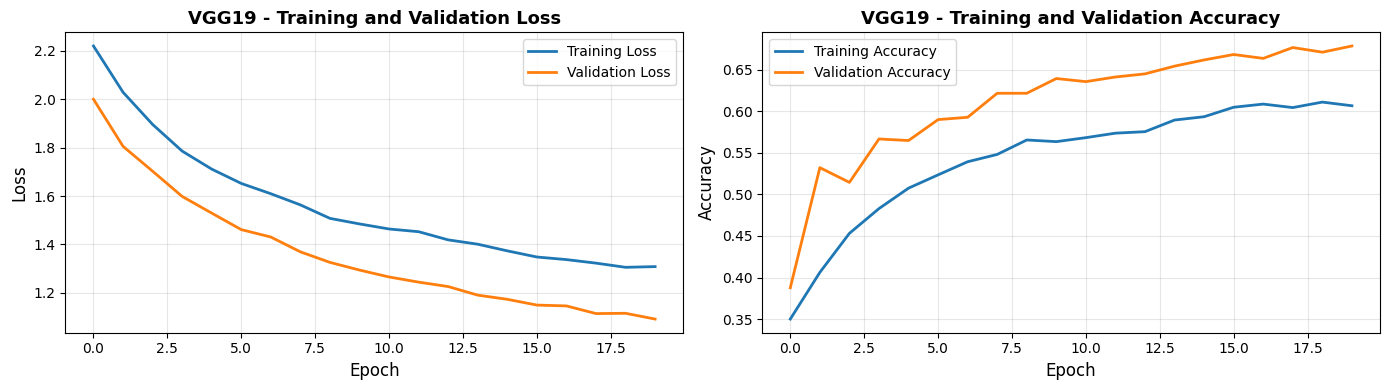

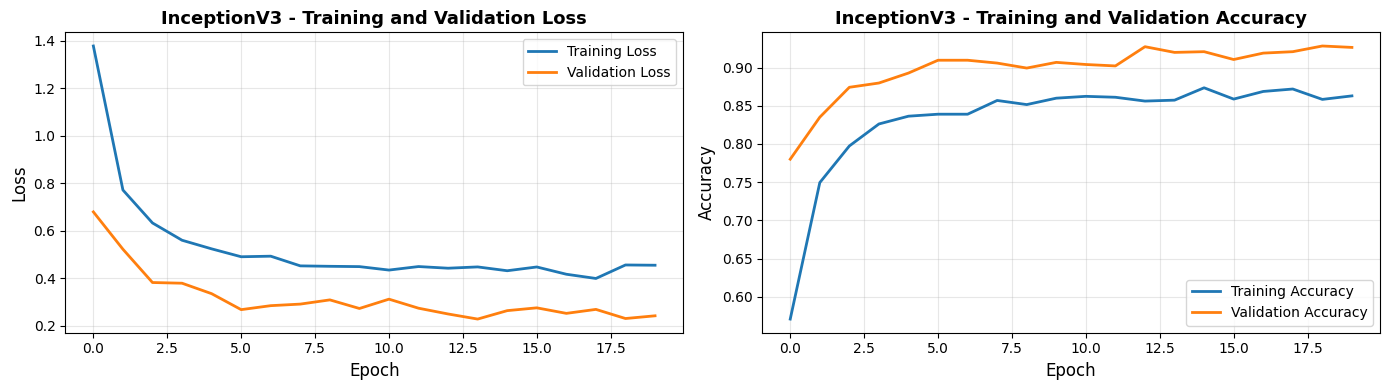

In [15]:
def plot_training_history(history, model_name):
    """Plot training and validation loss/accuracy"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f'{model_name} - Training and Validation Loss', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'{model_name} - Training and Validation Accuracy', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*70)
print("Plotting Training History...")
print("="*70)

plot_training_history(vgg19_history, 'VGG19')
plot_training_history(inception_history, 'InceptionV3')

In [16]:
# Get predictions
def get_predictions(model, test_gen):
    """Generate predictions for test dataset"""
    predictions = model.predict(test_gen)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes
    return pred_classes, true_classes, predictions

vgg19_pred, vgg19_true, vgg19_probs = None, None, None
inception_pred, inception_true, inception_probs = None, None, None


vgg19_pred, vgg19_true, vgg19_probs = get_predictions(vgg19_model, test_generator)

inception_pred, inception_true, inception_probs = get_predictions(inception_model, test_generator)

69/69 ━━━━━━━━━━━━━━━━━━━━ 878s 13s/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 26s 369ms/step


In [17]:
def compute_metrics(y_true, y_pred, model_name):
    """Compute and return evaluation metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    return metrics

# Compute metrics for pre-trained models
vgg19_metrics = None
inception_metrics = None

vgg19_metrics = compute_metrics(vgg19_true, vgg19_pred, 'VGG19')
inception_metrics = compute_metrics(inception_true, inception_pred, 'InceptionV3')

# Display metrics comparison
print("PRE-TRAINED MODELS PERFORMANCE METRICS")

metrics_list = []

metrics_list.append([vgg19_metrics['Model'], f"{vgg19_metrics['Accuracy']:.4f}",
  f"{vgg19_metrics['Precision']:.4f}", f"{vgg19_metrics['Recall']:.4f}",
  f"{vgg19_metrics['F1-Score']:.4f}"])


metrics_list.append([inception_metrics['Model'], f"{inception_metrics['Accuracy']:.4f}",
  f"{inception_metrics['Precision']:.4f}", f"{inception_metrics['Recall']:.4f}",
  f"{inception_metrics['F1-Score']:.4f}"])

metrics_df = np.array(metrics_list)

print(f"{'Model':<20} {'Accuracy':<15} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")
print("-" * 80)
for row in metrics_df:
    print(f"{row[0]:<20} {row[1]:<15} {row[2]:<15} {row[3]:<15} {row[4]:<15}")

PRE-TRAINED MODELS PERFORMANCE METRICS
Model                Accuracy        Precision       Recall          F1-Score       
--------------------------------------------------------------------------------
VGG19                0.6824          0.7059          0.6693          0.6669         
InceptionV3          0.9256          0.9281          0.9213          0.9226         


Generating Confusion Matrices...


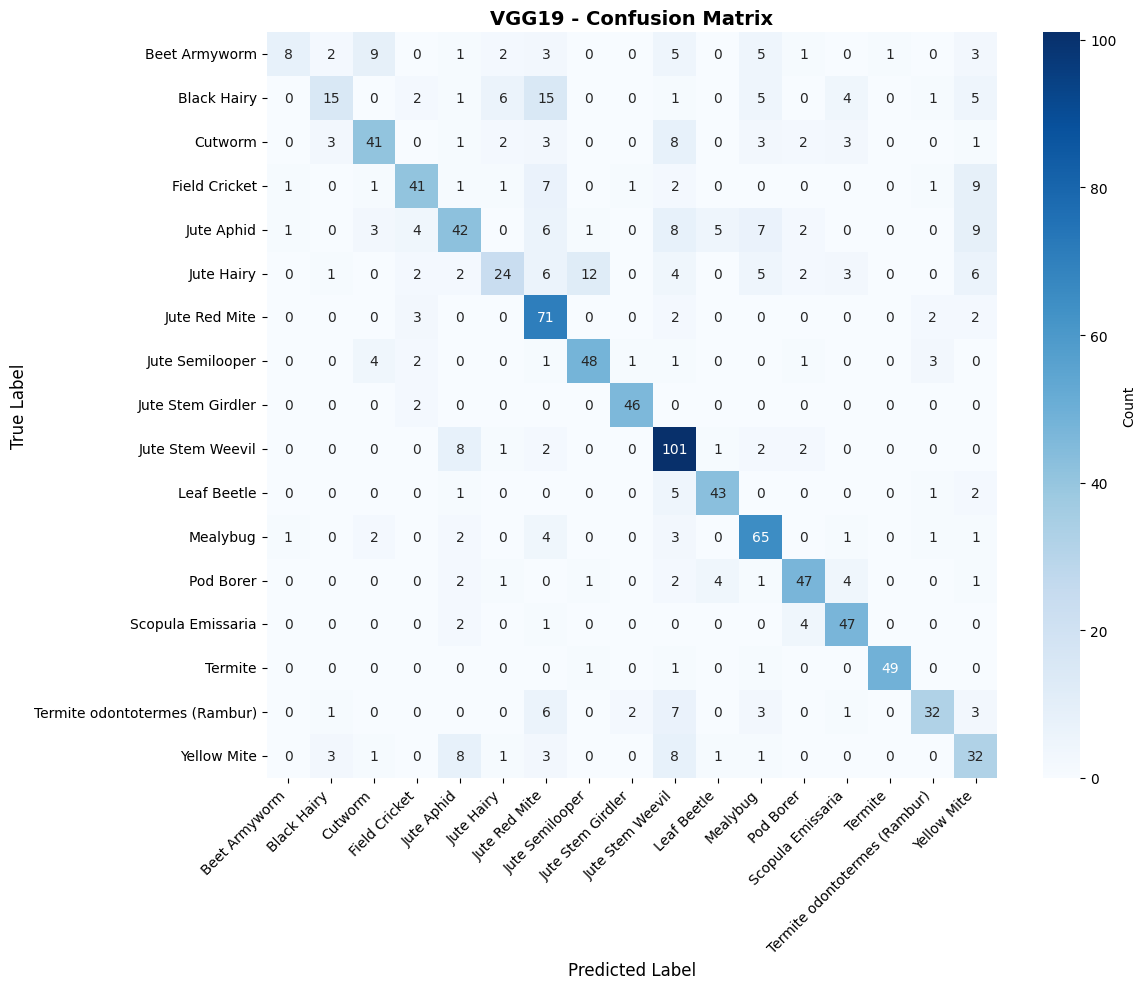

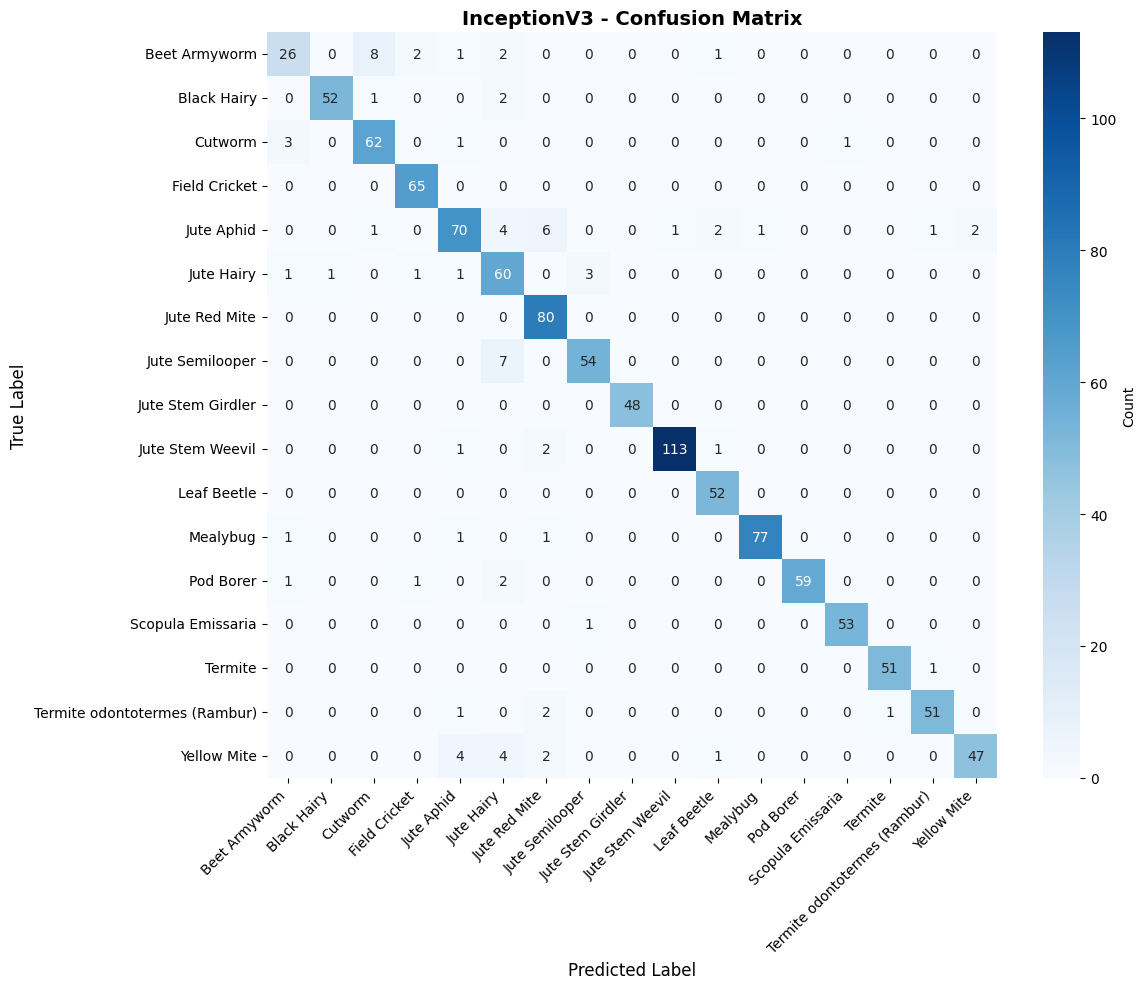



VGG19 Classification Report:
                               precision    recall  f1-score   support

                Beet Armyworm       0.73      0.20      0.31        40
                  Black Hairy       0.60      0.27      0.38        55
                      Cutworm       0.67      0.61      0.64        67
                Field Cricket       0.73      0.63      0.68        65
                   Jute Aphid       0.59      0.48      0.53        88
                   Jute Hairy       0.63      0.36      0.46        67
                Jute Red Mite       0.55      0.89      0.68        80
              Jute Semilooper       0.76      0.79      0.77        61
            Jute Stem Girdler       0.92      0.96      0.94        48
             Jute Stem Weevil       0.64      0.86      0.73       117
                  Leaf Beetle       0.80      0.83      0.81        52
                     Mealybug       0.66      0.81      0.73        80
                    Pod Borer       0.77     

In [18]:
def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, cbar_kws={'label': 'Count'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

class_names = list(train_generator.class_indices.keys())

print("Generating Confusion Matrices...")

plot_confusion_matrix(vgg19_true, vgg19_pred, 'VGG19', class_names)
plot_confusion_matrix(inception_true, inception_pred, 'InceptionV3', class_names)

print("\n\nVGG19 Classification Report:")
print(classification_report(vgg19_true, vgg19_pred, target_names=class_names, zero_division=0))
print("\n\nInceptionV3 Classification Report:")
print(classification_report(inception_true, inception_pred, target_names=class_names, zero_division=0))

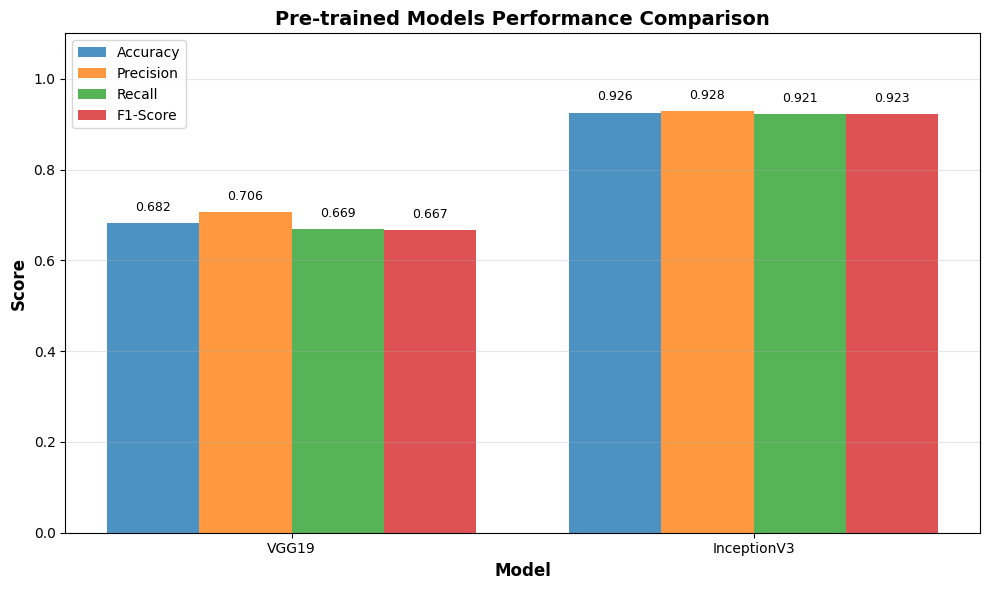

In [19]:
def plot_metrics_comparison():
    """Plot comparison of metrics across pre-trained models"""
    if vgg19_metrics is None and inception_metrics is None:
        print("No metrics available to plot")
        return

    models = []
    accuracy = []
    precision = []
    recall = []
    f1 = []


    models.append('VGG19')
    accuracy.append(vgg19_metrics['Accuracy'])
    precision.append(vgg19_metrics['Precision'])
    recall.append(vgg19_metrics['Recall'])
    f1.append(vgg19_metrics['F1-Score'])


    models.append('InceptionV3')
    accuracy.append(inception_metrics['Accuracy'])
    precision.append(inception_metrics['Precision'])
    recall.append(inception_metrics['Recall'])
    f1.append(inception_metrics['F1-Score'])

    x = np.arange(len(models))
    width = 0.2

    plt.figure(figsize=(10, 6))
    plt.bar(x - 1.5*width, accuracy, width, label='Accuracy', alpha=0.8)
    plt.bar(x - 0.5*width, precision, width, label='Precision', alpha=0.8)
    plt.bar(x + 0.5*width, recall, width, label='Recall', alpha=0.8)
    plt.bar(x + 1.5*width, f1, width, label='F1-Score', alpha=0.8)

    plt.xlabel('Model', fontsize=12, fontweight='bold')
    plt.ylabel('Score', fontsize=12, fontweight='bold')
    plt.title('Pre-trained Models Performance Comparison', fontsize=14, fontweight='bold')
    plt.xticks(x, models)
    plt.legend()
    plt.ylim([0, 1.1])
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i in range(len(models)):
        plt.text(i - 1.5*width, accuracy[i] + 0.02, f'{accuracy[i]:.3f}', ha='center', va='bottom', fontsize=9)
        plt.text(i - 0.5*width, precision[i] + 0.02, f'{precision[i]:.3f}', ha='center', va='bottom', fontsize=9)
        plt.text(i + 0.5*width, recall[i] + 0.02, f'{recall[i]:.3f}', ha='center', va='bottom', fontsize=9)
        plt.text(i + 1.5*width, f1[i] + 0.02, f'{f1[i]:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_metrics_comparison()

In [25]:
import pickle
import os
# Google Drive paths for Colab
saved_model = '/content/drive/MyDrive/Colab Notebooks/saved_models'

# Create directory for checkpoints
os.makedirs(saved_model, exist_ok=True)

# Save VGG19 history
if 'vgg19_history' in locals() and vgg19_history is not None:
    try:
        with open(os.path.join(saved_model, 'vgg19_history.pkl'), 'wb') as f:
            pickle.dump(vgg19_history.history, f)
        print(f"✓ VGG19 training history saved as '{os.path.join(saved_model, 'vgg19_history.pkl')}'")
    except Exception as e:
        print(f"✗ Error saving VGG19 history: {e}")
else:
    print("✗ VGG19 history not available to save.")

# Save InceptionV3 history
if 'inception_history' in locals() and inception_history is not None:
    try:
        with open(os.path.join(saved_model, 'inception_v3_history.pkl'), 'wb') as f:
            pickle.dump(inception_history.history, f)
        print(f"✓ InceptionV3 training history saved as '{os.path.join(saved_model, 'inception_v3_history.pkl')}'")
    except Exception as e:
        print(f"✗ Error saving InceptionV3 history: {e}")
else:
    print("✗ InceptionV3 history not available to save.")

✓ VGG19 training history saved as '/content/drive/MyDrive/Colab Notebooks/saved_models/vgg19_history.pkl'
✓ InceptionV3 training history saved as '/content/drive/MyDrive/Colab Notebooks/saved_models/inception_v3_history.pkl'
